## Project 2: 2D-Denoising Autoencoder (Random Shapes)

You are given a dataset of synthetic grayscale images containing random shapes (circles, rectangles, triangles).  
Each clean image has a corresponding noisy version with **Gaussian noise** added.

### 🔹 Important Notes
- You will train a **Denoising Autoencoder** on pairs of images:
  - Input  → noisy image  
  - Target → clean image  

The dataset structure:
```
random_shapes_dataset/
clean/ 0001.png, 0002.png, ...
noisy/ 0001.png, 0002.png, ...
```

Your goal is to **build, train, and evaluate a Denoising Autoencoder** that learns to reconstruct the clean image from the noisy input.

###  What You Must Do
1. **Load the data** (clean + noisy matched pairs)
2. **Build a convolutional autoencoder**
3. **Train the model** using `(noisy → clean)` images
4. **Show at least 3 visual comparisons**:
   - Clean  
   - Noisy  
   - Denoised (your model output)


### Load the Dataset (Starter Code)

```python
import os
import cv2
import numpy as np
from glob import glob

DATA_DIR = "random_shapes_dataset"
clean_dir = os.path.join(DATA_DIR, "clean")
noisy_dir = os.path.join(DATA_DIR, "noisy")

clean_files = sorted(glob(os.path.join(clean_dir, "*.png")))
noisy_files = sorted(glob(os.path.join(noisy_dir, "*.png")))

clean_images = []
noisy_images = []

for cfile, nfile in zip(clean_files, noisy_files):
    clean = cv2.imread(cfile, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
    noisy = cv2.imread(nfile, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

    clean_images.append(clean)
    noisy_images.append(noisy)

clean_images = np.array(clean_images)[..., np.newaxis]   # shape: (N, H, W, 1)
noisy_images = np.array(noisy_images)[..., np.newaxis]

print("Loaded shapes:", clean_images.shape, noisy_images.shape)


Loaded dataset shapes:
 clean : (1000, 64, 64, 1)
 noisy : (1000, 64, 64, 1)


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_4 (UpSampling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_5 (UpSampling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 64, 64, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 0.0940 - val_loss: 0.0560
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0411 - val_loss: 0.0258
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0258 - val_loss: 0.0225
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0223 - val_loss: 0.0172
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0139 - val_loss: 0.0117
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - loss: 0.0106 - val_loss: 0.0087
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0092 - val_loss: 0.0084
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0087 - val_loss: 0.0079
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0083 - val_loss: 0.0079
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - loss: 0.0080 - val_loss: 0.0074


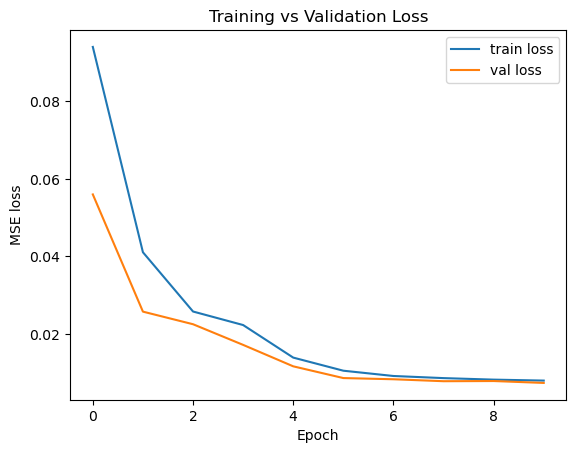

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


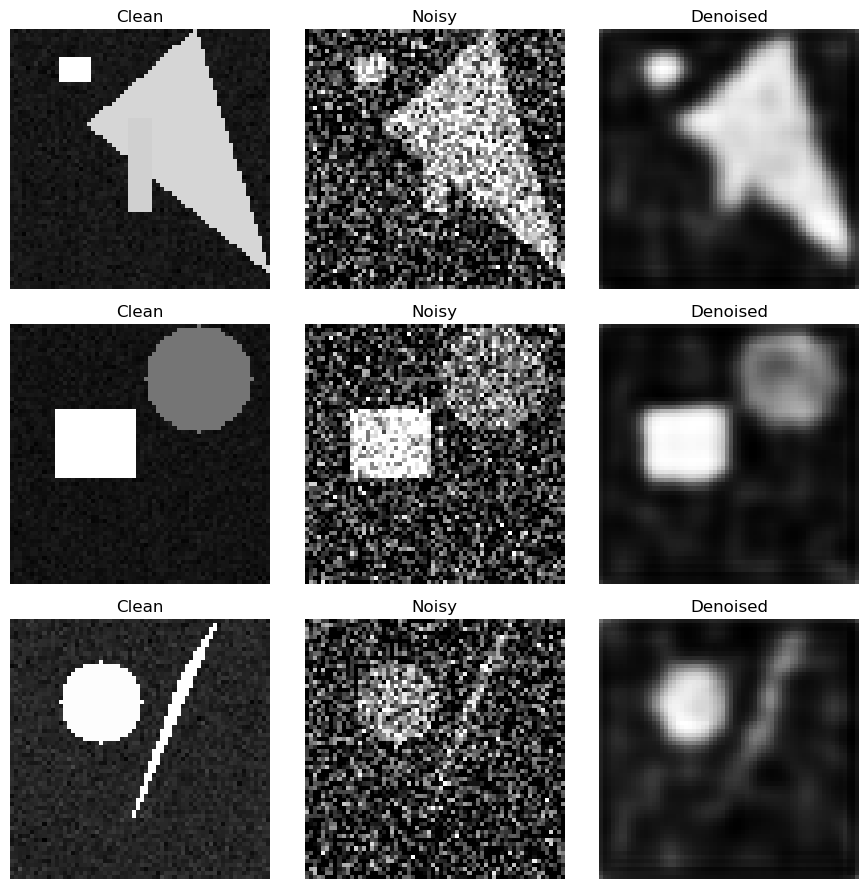

In [3]:
# ================================================================
#  Project 2 – Denoising Autoencoder (Sequential solution)
# ================================================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

# ------------------------------------------------
# 1. Load Dataset (clean + noisy)
# ------------------------------------------------
DATA_DIR = "random_shapes_dataset"   # adjust path if needed
clean_dir = os.path.join(DATA_DIR, "clean")
noisy_dir = os.path.join(DATA_DIR, "noisy")

clean_files = sorted(glob(os.path.join(clean_dir, "*.png")))
noisy_files = sorted(glob(os.path.join(noisy_dir, "*.png")))

clean_images = []
noisy_images = []

for cfile, nfile in zip(clean_files, noisy_files):
    clean = cv2.imread(cfile, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
    noisy = cv2.imread(nfile, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
    clean_images.append(clean)
    noisy_images.append(noisy)

clean_images = np.array(clean_images)[..., np.newaxis]   # (N, H, W, 1)
noisy_images = np.array(noisy_images)[..., np.newaxis]

print("Loaded dataset shapes:")
print(" clean :", clean_images.shape)
print(" noisy :", noisy_images.shape)

# Simple train/validation split
N = clean_images.shape[0]
split = int(0.8 * N)
x_train, x_val = noisy_images[:split], noisy_images[split:]
y_train, y_val = clean_images[:split], clean_images[split:]

H, W = clean_images.shape[1], clean_images.shape[2]

# ------------------------------------------------
# 2. Build Denoising Autoencoder (Sequential)
# ------------------------------------------------
autoencoder = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same",
           input_shape=(H, W, 1)),
    MaxPooling2D((2, 2), padding="same"),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),

    Conv2D(1, (3, 3), activation="sigmoid", padding="same")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# ------------------------------------------------
# 3. Train the Model
# ------------------------------------------------
history = autoencoder.fit(
    x_train, y_train,
    epochs=10,             # you can increase this for better results
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

# Plot training and validation loss
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# ------------------------------------------------
# 4. Visual Comparison: Clean / Noisy / Denoised
# ------------------------------------------------
num_examples = 3
indices = np.random.choice(N, num_examples, replace=False)

noisy_sample = noisy_images[indices]
clean_sample = clean_images[indices]
denoised_sample = autoencoder.predict(noisy_sample)

plt.figure(figsize=(9, 3 * num_examples))
for i in range(num_examples):
    # Clean
    plt.subplot(num_examples, 3, 3*i + 1)
    plt.imshow(clean_sample[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # Noisy
    plt.subplot(num_examples, 3, 3*i + 2)
    plt.imshow(noisy_sample[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(num_examples, 3, 3*i + 3)
    plt.imshow(denoised_sample[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()
